# Линейные модели

Модель линейной регрессии предполагает, что функция регрессии $E(Y|X)$ является линейной относительно входных переменных $X_1, ..., X_p$. Они просты и часто понятно описывают, как входные данные влиюят на отклик. В задачах предсказания они могут иногда превосходить более привлекательные нелинейные модели, особенно в ситуациях с небольшим количеством обучающих данных, низким отношением сигнал/шум или разреженными данными. Линейные модели, также можно применять к преобразованиям входных данных. 

---

Модель линейной регрессии:

Задача линейной регрессии - предсказать действительный отклик $Y$ по входному вектору $X^T = (X_1, X_2, ..., X_p)$, тогда модель линейной регрессии имеет вид:

$$f(X) = \beta_0 + \sum_{j=1}^p X_j B_j$$

Линейная модель предполагает, что либо функция регрессии $E(Y|X)$ является линейной, либо линейная модель является разумным приближением. Здесь $\beta_j$ являются неизвестными параметрами, или коэффициентами, а источниками переменных $X_j$ могут быть разными:

- Количественные данные

- преобразования количественных входных данных, такие как логарифм, квадратный корень или квадрат

- базисные разложения, такие как $X_2 = X_1^2$, $X_3 = X^3_1$ и т.д., приводящие к полиномиальному представлению.

- числовое, или "фиктивное", кодирование уровней качественных входных данных. Например, если $G$ является пятиуровневой входной переменной, то мы можем создать переменные $X_j, j = 1, ..., 5,$ такие, что $X_j = I(G = j)$. В совокупности эта группа переменных $X_j$ учитывает переменную $G$ с помощью множества констант, зависящих от уровня, поскольку в сумме $\sum^5_{j=1} X_j \beta_j$ один из элементов $X_j$ равен единице, а остальные равны нулю.

- взаимодействие переменных, например $X_3 = X_1 \cdot X_2$

Независимо от источника $X_j$, модель является линейной по параметрам.

Обычно у нас есть множество обучающих данных $(x_1, y_1), ..., (x_N, y_N)$ для оценки параметров $\beta$. Каждый вектор $x_i = (x_{i1}, x_{i2}, ..., x_{ip})^T$ является вектором измеренеий признаков для $i$-го варианта. Самый популярный метод оценки - МНК, в котором мы выбираем коэффициенты $\beta = (\beta_0, \beta_1, ..., \beta_p)^T$, которые минимизируют остаточную сумму квадратов: 

$$RSS(\beta) = \sum_{i=1}^N (y_i - f(x_i))^2 = \sum^N_{i=1} (y_i - \beta_0 - \sum^p_{j=1} x_{ij}\beta_j)^2$$

Со статистической точки зрения этот критерий является разумным, если обучающие наблюдения $(x_i, y_i)$ представляют собой независимые случайные выборки из соответствующей генеральной совокупности. Даже если величины $x_i$ не были извлечены случайным образом, критерий остается в силе, Если величины $y_i$ условно независимы при фиксированных значениях $x_i$. 

На рисунке 3.1. показана геометрическая интепретация МНК в пространстве $\R^{p+1}$, заполненном параметрами $(X,Y)$. Обратите внимание, что в формуле 3.2 не делается никаких предположений о справедливости модели 3.1, она просто находит наилучшее линейное соответствие данным. Аппроксимация по МНК интуитивно удовлетворяется независимо от происхождения данных, критерий измеряет среднюю погрешность аппроксимации. 


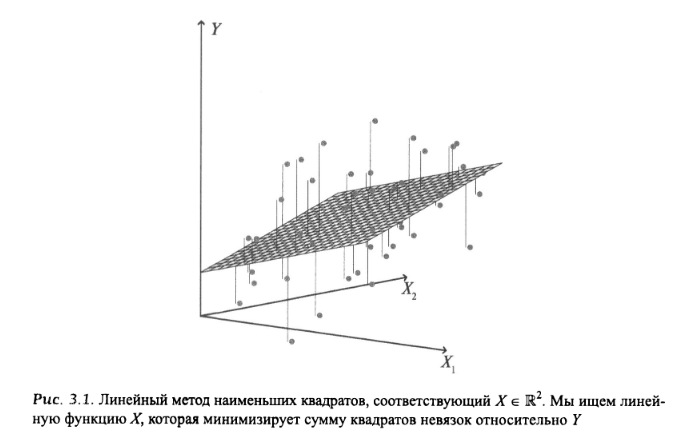

Для минимизации 3.2, нужно обозначить через $X$ матрицу размером $N \cdot (p+1)$, каждой строкой которой является входной вектор (с единицей в первой позиции), и аналогично пусть $y$ будет вектором, содержащим $N$ откликов из обучающего множества. Тогда остаточную сумму квадратов можно записать как 

$$RSS(\beta) = (y - X\beta)^T (y - X\beta)$$

Это квадратичная функция по $p + 1$ параметру. Дифференцируя по $\beta$, получим

$$\frac{\partial RSS}{\partial \beta} = - 2X^T (y-X\beta)$$

$$\frac{\partial^2 RSS}{\partial\beta\partial\beta^T} = 2X^TX$$

Предполагая (на данный момент), что матрица $X$ имеет полный ранг столбцов и, следовательно, матрица $X^T X$ положительно определена, приравниваем первую производную к нулю:

$$X^T (y - X \beta) = 0$$

и получаем единственное решение:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

Предсказанные значения на входном векторе $x_0$ определяются как $\hat{f}(x_0) = (1, x_0)^T \hat{\beta}$, приближенные значения на обучающих данных имеют вид 

$$\hat{y} = X \hat{\beta} = X(X^T X)^{-1} X^T y, \tag{3.7}$$

где $\hat{y_i} = \hat{f}(x_i)$. Матрицу $H = X(X^TX)^{-1} X^T$, из формулы (3.7), иногда называют "шляпной" матрицей, потому что она "надевает шляпу" на вектор $y$.

На рис 3.2. показано другое геометрическое представление оценки по МНК, в пространстве $\R^N$. Обозначим векторы столбцов матрицы $X$ через $x_0, x_1, ..., x_p$ при $x_0 \equiv 1$. В дальнейшем этот первый столбец рассматривается как любой другой. Эти векторы охватывают подпространство пространства $\R^N$, которые называются пространством столбцов матрицы $X$. Мы минимизируем ошибку $RSS(\beta) = ||y - X\beta||^2$, выбрав параметры $\hat{\beta}$ так, чтобы вектор невязки $y - \hat{y}$ был ортогонален этому подпространству. Эта ортогональность выражается формулой (3.5), и, следовательно, итоговая оценка $\hat{y}$ является ортогональной проекцией вектора $y$ на это подпространство. "Шляпная матрица" $H$ вычисляет ортогональную проекцию и поэтому также называется проекционной матрицей.

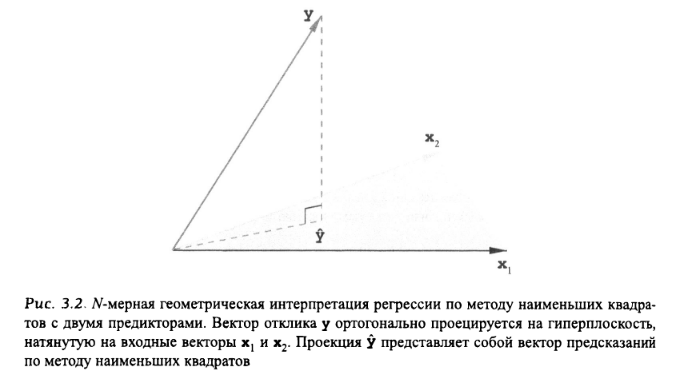

Иногда столбцы $x$ не являются линейно независимыми, так что матрица $X$ не имеет полного ранга. Это происходит, например когда две входные переменные являются идеально коррелированными (например $x_2 = 3x_1$). Тогда матрица $X^TX$ является вырожденной, и коэффициенты наименьших квадратов $\beta$ определяются неодназначно. Одако приближенные значения $\hat{y} = X\hat{\beta}$ по прежнему являются проекцией вектора $y$ на рпостранство столбцов матрицы $X$. Существует тольео несколько способов выразить эту проекцию в терминах векторов-столбцов матрицы $X$. Случай неполного ранга чаще всего возникает, когда одна или несколько качественных входных переменных кодируются избыточным образом. Обычно существует естественный способ устранения неединственного представления путем перекодироваия и/или удаления избыточных столбцов из матрицы $X$. Большинство библиотек для регрессии обнаруживают такую избыточность и автоматически реализуют некоторую стратегию их устранения. Неполные ранги также могут возникать при анализе сигналов и изображений, когда количество входных переменных $p$ может превышать количество обучающих выборок $N$. В этом случае количество признаков обычно уменьшается путем фильтрации или же выполняется регуляразация.

Чтобы определеить выборочные свойства вектора $\hat{\beta}$, предположим, что наблюдения $y_i$ не коррелированы и имеют постоянную дисперсию $\omega^2$, а значения $x_i$ фиксированы (не случайны). Ковариационная матрица оценок параметров по МНК выводится из 3.6 и определяется как 

$$Var(\hat{\beta}) = (X^TX)^{-1} \sigma^2$$

обычно дисперсию оценивают по формуле 

$$\hat{\sigma}^2 = \frac{1}{N - p - 1} \sum^N_{i = 1} (y_i - \hat{y_i})^2$$

В значменателе используется $N - p - 1$, а не $N$, чтобы оценка $\sigma^2$ стала несмещенной: $E(\hat{sigma}^2) = \sigma^2$

Чтобы сделать выводы о параметрах и модели, необходимы дополнительные предположения. Теперь предположим, что (3.1) является правильной моделью для математического ожидания, условное математическое ожидаине $Y$ является линейным относительно $X_1, ..., X_p$. Мы также предполагаем, что отклонения $Y$ от его математического ожидания являются аддитивными ин ормально распределенными. Следовательно, 

$$Y = E(Y | X_1, ..., X_P) + \varepsilon = \beta_0 + \sum_{j=1}^p X_j \beta_j + \varepsilon \tag{3.9}$$

где ошибка $\varepsilon$ является случайной нормальной дисперсией переменной с нулевым математическим ложиданием и дисперсией $\sigma^2$. Этот факт записывается как $\sigma \sim N(0, \sigma^2)$.

из формулы 3.9:

$$\hat{\beta} \sim  N(\beta, (X^TX)^{-1} \sigma^2) \tag{3.10}$$

Это многомерное нормальное распределение с вектором математических ожиданий и ковариационной матрицей. Кроме того,

$$(N - p - 1) \sigma^2 \sim \sigma^2 \chi^2_{N - p - 1} \tag{3.11}$$

т.е. это - распределение кси-квадрат с $N - p -1$ степенями свободы. Кроме того, величины $\hat{\beta}$ и $\hat{\sigma}^2$ статистически независимы. Мы используем эти свойства распределеия при построении критериев для проверки гипотез и вычисления доверительных интервалов, содержащих параметры $\beta_j$.

Чтобы проерить гипотезу о том, что конкретный коэффициент $\beta_j$ равен нулю, вычислим стандартизированный коэффициент, или $Z$-оценку:

$$z_j = \frac{\hat{\beta_j}}{\hat{\sigma}\sqrt{v_j}}$$

где v_j - j_й диагональный элемент матрицы $(X^T X)^-1$. При нулевой гипотезы, утверждающей, что $\beta_j = 0$, случайная величина $z_j$ имеет $t$-распределение с $N - p - 1$ степенью свободы, и, следовательно, большое (абсолютное) значение $z_j$ приведет к отклонению этой нулевой гипотезы. Если параметр $\hat{sigma}$ заменяется известным значением $\sigma$, то случайная величина $z_j$ будет иметь стандартное нормальное распределение. По мере увеличения размера выорки разница между хвостовыми квантилями $t$-распределения и стандартного нормально распределения становится незначительной, поэтому обычно используются нормальные квантили.

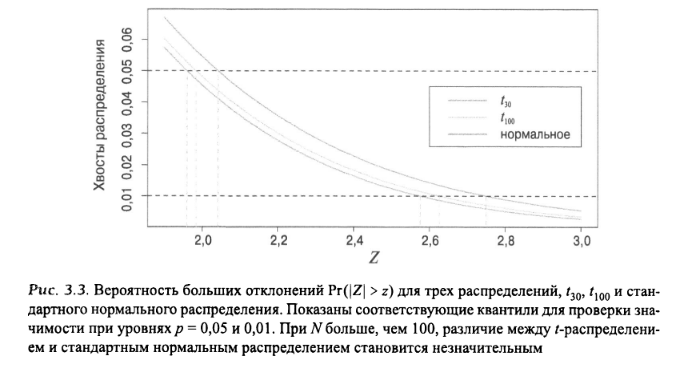